## 1. Imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.manifold import TSNE
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import hdbscan

## 2. Excel loading

In [2]:
RAW_FILE, SHEET = "ESB_v8.xlsx", "1. District-level data"
MISSING_DATA    = {"Missing value","Blank cell","TBD","N/A","NA",""," "}

df = (pd.read_excel(RAW_FILE, sheet_name=SHEET)
        .replace(list(MISSING_DATA), np.nan))
print(f"✓ fichier lu : {df.shape}")


✓ fichier lu : (19516, 91)


## 3. Make sure columns are <= 2 words long + rebrand column names

In [3]:
def slugify(col, n_words=2):
    col = col.strip()
    m   = re.match(r"(?P<code>\d+[a-z])\.\s*(?P<rest>.+)", col, flags=re.I)
    code = (m["code"] + "_") if m else ""
    rest = m["rest"] if m else col
    base = "_".join(re.sub(r"[^0-9a-zA-Z ]", " ", rest)
                    .split()[:n_words]).lower()
    return code + base

new_cols = pd.Series(df.columns).apply(slugify)

seen = {}
for i, c in enumerate(new_cols):
    seen[c] = seen.get(c, 0) + 1
    new_cols[i] = f"{c}_{seen[c]}" if seen[c] > 1 else c
df.columns = new_cols

## 4. yes/no → Int8 booleans

In [4]:
yn_cols = [
    c for c in df.columns
    if df[c].dropna().isin({"yes", "no", "Yes", "No"}).all() # check if all values are yes/no
]
df[yn_cols] = df[yn_cols].apply(
    lambda s: s.str.lower().map({"yes": 1, "no": 0}).astype("Int8") # convert to 1/0
)

print("✓ yes/no convertis :", len(yn_cols), "colonnes")

✓ yes/no convertis : 8 colonnes


## 4. Convert columns to numerical variables using coerce

In [5]:
def try_numeric(s):
    ratio_numeric = pd.to_numeric(s, errors="coerce").notna().mean()
    if ratio_numeric > 0.95:
        return pd.to_numeric(s, errors="coerce")
    else:
        return s

df = df.apply(try_numeric)
print("✓ conversion numérique")

✓ conversion numérique


## 5. Variables selection based on scenarios

In [6]:
# slugs réels (vérifiés dans df.columns)
AXIS_COLS      = ["3a_number_of","3f_number_of","3i_percent_of"]
ECO_COLS      = ["5d_percent_low", "5n_qualified_for", "5o_epa_2022", "5p_epa_2023"]
DIVERSITY_COLS = ["5b_percent_non"]

BASE_VARS      = AXIS_COLS + ECO_COLS + DIVERSITY_COLS
PASS1_VARS = BASE_VARS + ["4f_median_household","4u_percent_hispanic"]
PASS2_VARS = PASS1_VARS + ["4g_percent_poverty","4e_percent_free",
                           "4j_percent_black","4n_percent_asian"]
print("✓ listes prêtes")

✓ listes prêtes


## 6. Common pipeline for each scenario

Silhouette t-SNE k=4 : 0.463


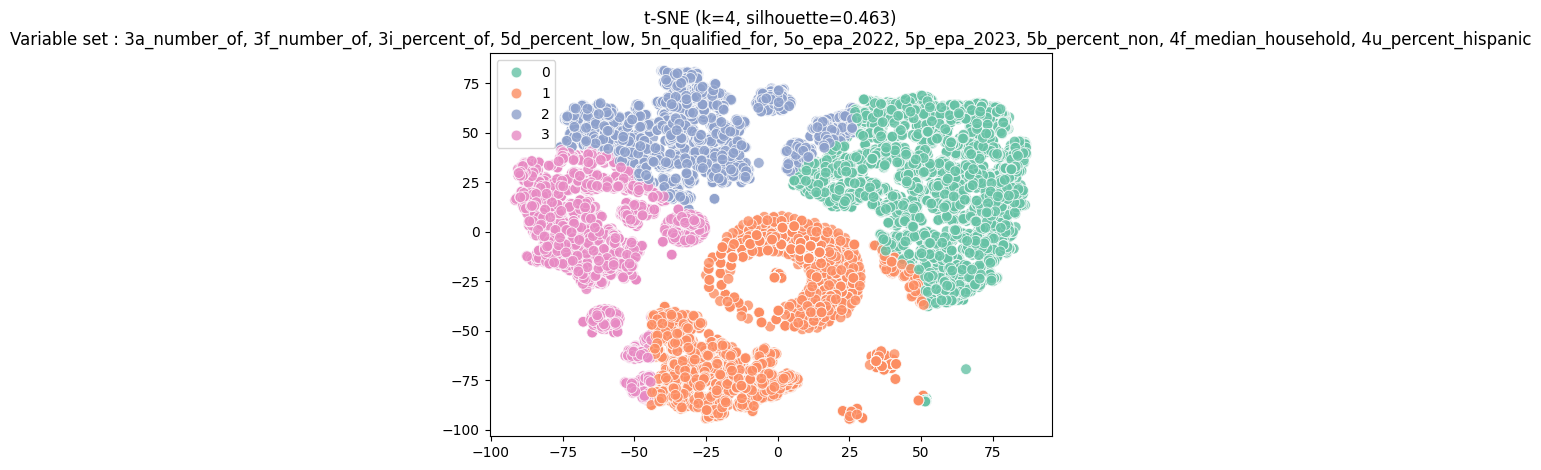

In [ ]:
# ----- 1. Use a variable set and rename columns -------------------
feat = df[PASS1_VARS].copy()          # ← replace with PASS1_VARS or PASS2_VARS
feat.rename(columns={
    "3a_number_of":"num_esb_committed",
    "3f_number_of":"num_esb_operating",
    "3i_percent_of":"pct_esb_operating",
    "5b_percent_non":"pct_nonwhite",
    "5d_percent_low":"pct_lowinc",
    "5n_qualified_for":"rescue_plan",
    "5o_epa_2022":"epa_2022",
    "5p_epa_2023":"epa_2023",
    "4f_median_household":"median_household",
    "4u_percent_hispanic":"pct_hispanic",
    
}, inplace=True)

# ----- 2. Preprocessing ---------------------------------------------------
num_cols = feat.select_dtypes("number").columns
preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("yj" , PowerTransformer("yeo-johnson", standardize=False)),
        ("sc" , RobustScaler())]), num_cols)])
X = preproc.fit_transform(feat)

# ----- 3. t-SNE ---------------------------------------------------------
emb = TSNE(2, perplexity=30, init="pca",
           learning_rate="auto", random_state=42).fit_transform(X)

# ----- 4. K-Medoids k=6 -------------------------------------------------
kmed = KMedoids(6, metric="manhattan",
                init="k-medoids++", random_state=42).fit(emb)
sil  = silhouette_score(emb, kmed.labels_, metric="manhattan")
print(f"Silhouette t-SNE k=6 : {sil:.3f}")

# ----- 5. Plot t-SNE ----------------------------------------------------
sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=kmed.labels_,
                palette="Set2", s=60, alpha=.8)
plt.title(f"t-SNE (k=4, silhouette={sil:.3f})\n"
          f"Variable set : {', '.join(PASS1_VARS)}")
plt.tight_layout()
plt.show()


In [9]:
profiles = pd.DataFrame({
    "num_esb_committed": feat["num_esb_committed"],
    "num_esb_operating": feat["num_esb_operating"],
    "pct_esb_operating": feat["pct_esb_operating"],
    "pct_nonwhite": feat["pct_nonwhite"],
    "pct_lowinc": feat["pct_lowinc"],
    "rescue_plan": feat["rescue_plan"],
    "epa_2022": feat["epa_2022"],
    "epa_2023": feat["epa_2023"],
    "median_household": feat["median_household"],
    "pct_hispanic": feat["pct_hispanic"],
    "cluster": kmed.labels_ 
})
profiles = profiles.groupby("cluster").mean().reset_index()
display(profiles)


,cluster,num_esb_committed,num_esb_operating,pct_esb_operating,pct_nonwhite,pct_lowinc,rescue_plan,epa_2022,epa_2023,median_household,pct_hispanic
0,0,0.674347,0.270087,0.015776,0.196505,0.204395,0.034076,0.010649,0.00213,87615.609886,0.080301
1,1,0.205762,0.035696,0.006440,0.120995,0.260238,0.04564,0.249873,0.000255,67102.875765,0.057548
2,2,1.884085,0.430451,0.036369,0.473869,0.383244,0.071742,0.757206,0.840226,53728.896823,0.261816
3,3,0.320664,0.073906,0.021763,0.115463,0.333257,0.055807,0.946606,0.852187,53189.511398,0.023636


- **Segmentation t-SNE (k-medoids, K=4, silhouette=0.46) sur variables :**  
    Base + revenu médian + % hispanique.

- **Clusters principaux :**  
    1. **#0** : Districts aisés (revenu ≈ 88k$), peu hispaniques (8%), peu de subventions, moteurs sans aides.  
    2. **#1** : Riches (67k$), peu hispaniques (6%), subventions EPA (25%) mais faible adoption, dépendants des aides.  
    3. **#2** : Moins favorisés (54k$), hispaniques majoritaires (26%), diversité élevée (43% non-white), adoption ESB forte, subventions EPA/ARP importantes.  
    4. **#3** : Pauvres/ruraux (53k$), très peu hispaniques (2%), subventions EPA maximales (95%), faible adoption.

- **Effet des nouvelles variables :**  
    - L’ajout du revenu et du % hispanique segmente l’ancien groupe “aisé” en deux sous-groupes :  
        - #0 : moteurs sans aides  
        - #1 : dépendants des subventions  
    - Le cluster diversité (#2) devient plus net, surtout hispanique.
    - Silhouette un peu plus basse qu’en baseline (0.46 vs 0.56) : meilleure segmentation transversale, mais groupes moins compacts.


c:\Users\danfy\anaconda3\envs\iris_classification\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP silhouette : 0.727


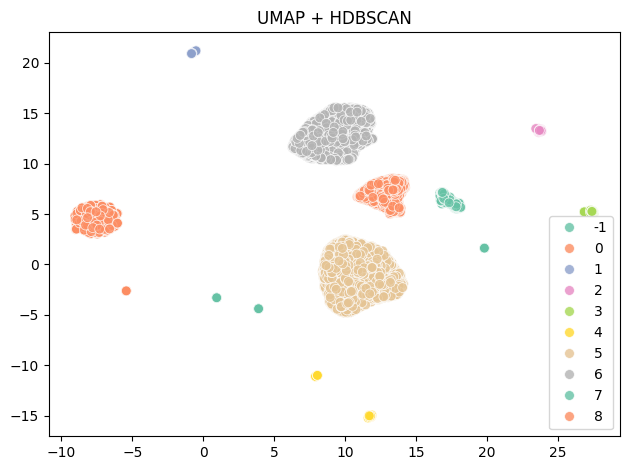

In [10]:
# ----- 6. UMAP + HDBSCAN -----------------------------------
um = umap.UMAP(n_neighbors=25, min_dist=0.05,
               metric="manhattan", random_state=42).fit_transform(X)
hdb = hdbscan.HDBSCAN(min_cluster_size=60, metric="manhattan").fit(um)
mask = hdb.labels_!=-1
if mask.any():
    silU = silhouette_score(um[mask], hdb.labels_[mask], metric="manhattan")
    print("UMAP silhouette :", round(silU,3))
sns.scatterplot(x=um[:,0], y=um[:,1], hue=hdb.labels_,
                palette="Set2", s=50, alpha=.8)
plt.title("UMAP + HDBSCAN")
plt.tight_layout()
plt.show()

## 7. Profile for each clustering scenario

In [12]:
feat["cluster"] = kmed.labels_ 
profile = (feat.groupby("cluster")[num_cols]
           .agg(["median","mean"])
           .T.round(2))
profile.head(15)

cluster                          0         1         2         3
num_esb_committed median       0.0       0.0       0.0       0.0
                  mean    0.674347  0.205762  1.884085  0.320664
num_esb_operating median       0.0       0.0       0.0       0.0
                  mean    0.270087  0.035696  0.430451  0.073906
pct_esb_operating median       0.0       0.0       0.0       0.0
                  mean    0.015776   0.00644  0.036369  0.021763
pct_lowinc        median  0.200212  0.262482  0.378375  0.336855
                  mean    0.204395  0.260238  0.383244  0.333257
rescue_plan       median       0.0       0.0       0.0       0.0
                  mean    0.034076   0.04564  0.071742  0.055807
epa_2022          median       0.0       0.0       1.0       1.0
                  mean    0.010649  0.249873  0.757206  0.946606
epa_2023          median       0.0       0.0       1.0       1.0
                  mean     0.00213  0.000255  0.840226  0.852187
pct_nonwhite      median  0.153971  0.083042  0.431437  0.079764

- **UMAP + HDBSCAN (silhouette = 0.73, bien supérieur à la base)**  
- Les clusters UMAP recoupent et affinent ceux de t-SNE :  
    - **0 (orange)** : riches, scindés entre engagés et freinés.
    - **2 (vert)** : cœur du cluster hispanique, forte cohésion, “best practices”.
    - **6 (gris)** : pauvres ruraux, EPA, groupe compact, ciblage facile.
    - **4/5 (jaunes)** : micropôles, hispaniques isolés ou outliers aisés.
    - **-1 (bruit)** : cas marginaux/anomalies.
- **Message clé :**  
    - Score silhouette élevé → ajout revenu + % hispanique renforce la structure.
    - Nouvelle segmentation haut-revenu bien perçue (orange/jaune).
    - Bloc hispanique (vert) reste très cohérent.
- **Verdict :**  
    - Séparation riches engagés/freinés : oui (#0 vs #1).
    - Sous-groupe hispanique isolé : oui (#2).
    - Lisibilité améliorée (silhouette UMAP ↑, t-SNE ↓ modéré).
    - Ajout des variables pertinent, à garder pour la suite.
- **Prochaine étape :**  
    - Ajouter pauvreté et % Black/Asian pour tester la subdivision du groupe pauvre blanc et l’amélioration de la silhouette.